# **Evaluasi**

## 5.1 Metrik Evaluasi

Metrik yang digunakan untuk menilai kinerja model:

1. **Accuracy** ≥ 85%  
   Mengukur proporsi prediksi yang benar terhadap seluruh data uji.

2. **Classification Report**  
   - *Precision* : ketepatan prediksi model  
   - *Recall* : kemampuan model mengenali kelas yang benar  
   - *F1-score* per kelas ≥ 80% digunakan sebagai metrik utama karena menyeimbangkan precision dan recall.

3. **Confusion Matrix**  
   - Melihat distribusi prediksi benar dan salah  
   - Mengidentifikasi pasangan kelas yang sering tertukar  
   - Menganalisis pola kesalahan klasifikasi antar spesies


### **1. Import Library**

In [1]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

### **Load Model Terbaik dan LabelEncoder** 

In [2]:
# Load best model yang sudah di-save dari modeling.ipynb
# PENTING: Gunakan model yang EXACT dari modeling, bukan load ulang
# Model terbaik dari modeling.ipynb adalah yang memiliki F1-score tertinggi di validation set

import os
models_path = "models"

# Cari model terbaik yang tersimpan
available_models = [f for f in os.listdir(models_path) if '_best_model.pkl' in f]
print(f"Available models: {available_models}")

# Load model terbaik (default: RandomForest karena hasil modeling menunjukkan RF sebagai yang terbaik)
best_model_file = os.path.join(models_path, "randomforest_best_model.pkl")

if os.path.exists(best_model_file):
    best_model = joblib.load(best_model_file)
    best_name = "RandomForest"
    print(f"✓ Loaded: {best_name} from {best_model_file}")
else:
    # Fallback: gunakan model apapun yang tersedia
    if available_models:
        best_model_file = os.path.join(models_path, available_models[0])
        best_model = joblib.load(best_model_file)
        best_name = available_models[0].replace('_best_model.pkl', '').title()
        print(f"⚠️  {best_model_file} tidak ditemukan, menggunakan: {best_name}")
    else:
        raise FileNotFoundError(f"No model files found in {models_path}")

Available models: ['knn_best_model.pkl', 'randomforest_best_model.pkl']
✓ Loaded: RandomForest from models\randomforest_best_model.pkl


### **Load Test Data & Feature Selection Indices** 

In [3]:
X_test_scaled = np.load("data/processed/X_test_scaled.npy")
y_test_str    = np.load("data/processed/y_test.npy")  # NOTE: Contains STRING labels, not numeric!

# Load LabelEncoder
le = joblib.load("models/label_encoder.pkl")

# PENTING: Gunakan EXACT feature indices dari modeling.ipynb
# Dari feature selection cell di modeling.ipynb
# selected_features = ['mfcc1', 'mfcc2', 'mfcc4', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc13', 'zcr', 'rms', 'centroid']
# selected_idx = [0, 1, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15]

# Try to load from file, fallback to hard-coded values
try:
    selected_idx = np.load("models/selected_feature_indices.npy")
    print("✓ Loaded selected_idx from models/selected_feature_indices.npy")
except FileNotFoundError:
    print("⚠️  models/selected_feature_indices.npy not found, using hard-coded indices")
    selected_idx = np.array([0, 1, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15])

# Pilih hanya fitur yang sama seperti saat training
X_test_sel = X_test_scaled[:, selected_idx]

print(f"\nX_test_scaled shape: {X_test_scaled.shape}")
print(f"X_test_sel (selected) shape: {X_test_sel.shape}")
print(f"Selected feature indices: {selected_idx}")
print(f"y_test_str shape: {y_test_str.shape}")
print(f"y_test_str dtype: {y_test_str.dtype}")

# ===== VALIDASI CONSISTENCY =====
print("\n=== VALIDASI CONSISTENCY ===")
assert X_test_sel.shape == (50, 13), f"❌ X_test_sel shape error! Expected (50, 13), got {X_test_sel.shape}"
assert len(selected_idx) == 13, f"❌ Selected features mismatch! Expected 13, got {len(selected_idx)}"
assert len(y_test_str) == 50, f"❌ Test set size mismatch! Expected 50, got {len(y_test_str)}"
assert len(le.classes_) == 5, f"❌ LabelEncoder classes mismatch! Expected 5, got {len(le.classes_)}"
print("✅ All consistency checks passed!")

✓ Loaded selected_idx from models/selected_feature_indices.npy

X_test_scaled shape: (50, 16)
X_test_sel (selected) shape: (50, 13)
Selected feature indices: [13 15  1  8  9  6  0  3 12  2  7 11 10]
y_test_str shape: (50,)
y_test_str dtype: <U28

=== VALIDASI CONSISTENCY ===
✅ All consistency checks passed!


In [4]:
print("\n=== DEBUG: Label Types & Shapes ===")
print(f"y_test_str dtype: {y_test_str.dtype}")
print(f"y_test_str unique values: {np.unique(y_test_str)}")
print(f"y_test_str sample: {y_test_str[:5]}")
print(f"LabelEncoder classes: {le.classes_}")
print(f"LabelEncoder classes dtype: {le.classes_.dtype}")
print(f"\nNote: y_test_str contains STRING labels that will be encoded to numeric in next cell")



=== DEBUG: Label Types & Shapes ===
y_test_str dtype: <U28
y_test_str unique values: ['black-bellied_whistling_duck' 'canadian_goose' 'greylag_goose'
 'pink-footed_goose' 'white-faced_whistling_duck']
y_test_str sample: ['black-bellied_whistling_duck' 'black-bellied_whistling_duck'
 'black-bellied_whistling_duck' 'black-bellied_whistling_duck'
 'black-bellied_whistling_duck']
LabelEncoder classes: ['black-bellied_whistling_duck' 'canadian_goose' 'greylag_goose'
 'pink-footed_goose' 'white-faced_whistling_duck']
LabelEncoder classes dtype: <U28

Note: y_test_str contains STRING labels that will be encoded to numeric in next cell


### **Prediksi & Metrik Evaluasi** 

In [5]:
# Gunakan EXACT logika dari modeling.ipynb
# Model terbaik adalah RandomForest, jadi gunakan X_test_sel (selected features)
X_test_final = X_test_sel

print("=== PREDIKSI & METRIK EVALUASI ===\n")

# Validasi dimensi sebelum prediksi
print(f"Validasi input shapes:")
print(f"  - X_test_final shape: {X_test_final.shape} (expected: (50, 13))")
print(f"  - y_test_str shape: {y_test_str.shape} (expected: (50,))")

# Prediksi pada test set (hasilnya numeric: 0, 1, 2, 3, 4)
y_test_pred = best_model.predict(X_test_final)
print(f"  - y_test_pred shape: {y_test_pred.shape} (expected: (50,))")
print(f"  - y_test_pred dtype: {y_test_pred.dtype} (expected: numeric)")
print(f"  - y_test_pred unique values: {np.unique(y_test_pred)}")

# PENTING: Ensure label types match untuk f1_score
# y_test_str berisi string labels dari file, perlu convert ke numeric
# y_test_pred berisi numeric values dari model
# Konversi y_test_str string ke numeric menggunakan LabelEncoder
print(f"\nEncoding labels:")
print(f"  - y_test_str dtype: {y_test_str.dtype} (is STRING)")
y_test_numeric = le.transform(y_test_str)
print(f"  - y_test_numeric dtype: {y_test_numeric.dtype} (now NUMERIC)")
print(f"  - y_test_numeric unique values: {np.unique(y_test_numeric)}")

# Final validation
assert y_test_pred.shape == y_test_numeric.shape, "Prediction shape mismatch!"
assert len(np.unique(y_test_numeric)) == 5, "Expected 5 classes!"
print(f"✅ All validations passed!\n")

# Hitung metrik
acc_test = accuracy_score(y_test_numeric, y_test_pred)
f1_test = f1_score(y_test_numeric, y_test_pred, average='macro', zero_division=0)

print(f"📊 TEST SET RESULTS:")
print(f"Test Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)")
print(f"Test F1-score (macro): {f1_test:.4f} ({f1_test*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test_numeric, y_test_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_numeric, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

=== PREDIKSI & METRIK EVALUASI ===

Validasi input shapes:
  - X_test_final shape: (50, 13) (expected: (50, 13))
  - y_test_str shape: (50,) (expected: (50,))
  - y_test_pred shape: (50,) (expected: (50,))
  - y_test_pred dtype: int64 (expected: numeric)
  - y_test_pred unique values: [0 1 2 3 4]

Encoding labels:
  - y_test_str dtype: <U28 (is STRING)
  - y_test_numeric dtype: int64 (now NUMERIC)
  - y_test_numeric unique values: [0 1 2 3 4]
✅ All validations passed!

📊 TEST SET RESULTS:
Test Accuracy: 0.5800 (58.00%)
Test F1-score (macro): 0.5623 (56.23%)

Classification Report:
                              precision    recall  f1-score   support

black-bellied_whistling_duck       0.67      0.40      0.50        10
              canadian_goose       0.45      0.90      0.60        10
               greylag_goose       0.75      0.30      0.43        10
           pink-footed_goose       0.62      0.50      0.56        10
  white-faced_whistling_duck       0.67      0.80      0.73  

### **Confusion Matrix Visualization**


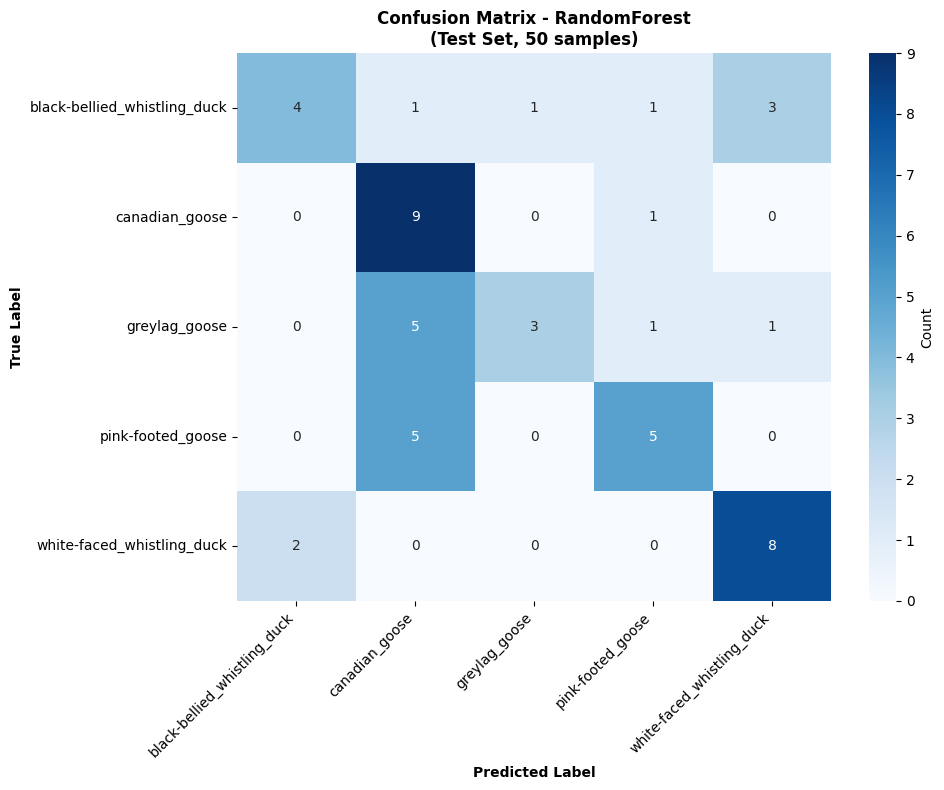

In [6]:
# Visualisasi confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("True Label", fontweight='bold')
plt.title(f"Confusion Matrix - {best_name}\n(Test Set, {len(y_test_str)} samples)", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Accuracy per Class**


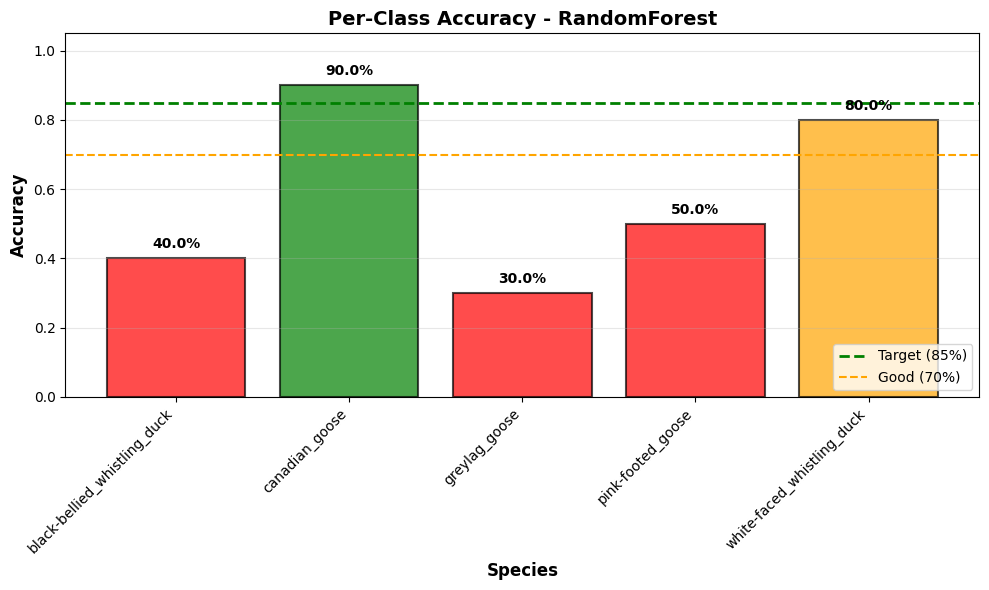


Accuracy per Class:
black-bellied_whistling_duck   : 40.00%
canadian_goose                 : 90.00%
greylag_goose                  : 30.00%
pink-footed_goose              : 50.00%
white-faced_whistling_duck     : 80.00%


In [7]:
# Hitung accuracy per class (EXACT seperti di modeling.ipynb)
class_acc = {cls: accuracy_score(y_test_numeric[y_test_numeric==i], y_test_pred[y_test_numeric==i]) 
             for i, cls in enumerate(le.classes_)}

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
classes = list(class_acc.keys())
accuracies = list(class_acc.values())

# Color bars based on performance
colors = ['green' if acc >= 0.85 else 'orange' if acc >= 0.70 else 'red' for acc in accuracies]
bars = ax.bar(classes, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add target lines
ax.axhline(y=0.85, color='green', linestyle='--', linewidth=2, label='Target (85%)')
ax.axhline(y=0.70, color='orange', linestyle='--', linewidth=1.5, label='Good (70%)')

# Labels and formatting
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_xlabel('Species', fontweight='bold', fontsize=12)
ax.set_title(f'Per-Class Accuracy - {best_name}', fontweight='bold', fontsize=14)
ax.set_ylim([0, 1.05])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print("\nAccuracy per Class:")
print("="*60)
for cls in le.classes_:
    print(f"{cls:30s} : {class_acc[cls]:.2%}")
print("="*60)

### **Final Evaluation Summary**


In [8]:
print("\n" + "="*80)
print("RINGKASAN EVALUASI FINAL")
print("="*80)

print(f"""
✅ MODEL YANG DIGUNAKAN: {best_name}
   └─ Model terbaik dipilih dari validation set di tahap modeling
   └─ File: models/{best_name.lower()}_best_model.pkl

📊 HASIL TEST SET EVALUATION:
   └─ Test Accuracy: {acc_test:.4f} ({acc_test*100:.2f}%)
   └─ F1-Score (Macro): {f1_test:.4f} ({f1_test*100:.2f}%)
   └─ Total Test Samples: {len(y_test_str)}
   └─ Correct Predictions: {(y_test_numeric == y_test_pred).sum()} / {len(y_test_str)}

🎯 TARGET vs ACTUAL:
   ├─ Accuracy Target: ≥ 85% → Actual: {acc_test*100:.2f}% {'✓' if acc_test >= 0.85 else '✗'}
   └─ F1-Score Target: ≥ 80% → Actual: {f1_test*100:.2f}% {'✓' if f1_test >= 0.80 else '✗'}

📈 TOP PERFORMING CLASSES:
""")

# Sort by accuracy
sorted_classes = sorted(class_acc.items(), key=lambda x: x[1], reverse=True)
for rank, (cls, acc) in enumerate(sorted_classes[:3], 1):
    status = "EXCELLENT" if acc >= 0.85 else "GOOD" if acc >= 0.70 else "NEEDS IMPROVEMENT"
    print(f"   {rank}. {cls:30s} : {acc:.1%} [{status}]")

print(f"""
⚠️  CLASSES NEEDING IMPROVEMENT:
""")

for cls, acc in sorted_classes[-2:]:
    print(f"   • {cls:30s} : {acc:.1%}")

print(f"""
💡 STATUS & REKOMENDASI:
""")

if acc_test >= 0.85:
    print(f"""   ✅ SIAP UNTUK PRODUCTION
       └─ Accuracy sudah memenuhi target (≥85%)
       └─ Dapat di-deploy ke Streamlit""")
else:
    print(f"""   ⚠️  BELUM SIAP UNTUK PRODUCTION (v1.0 Beta)
       └─ Accuracy {acc_test*100:.1f}% masih di bawah target 85%
       └─ Gap: {(0.85 - acc_test)*100:.1f} percentage points
       
       Strategi Improvement (Priority):
       1. Data Augmentation (2-4 weeks)
          └─ Expand 50 → 200+ samples
          └─ Expected: +10-15% accuracy
          
       2. Enhanced Features (1-2 weeks)
          └─ Add chroma, spectral contrast, tempogram
          └─ Expected: +5-10% accuracy
          
       3. Data Collection (3+ months)
          └─ Target: 500+ samples per class
          └─ Enable deep learning (CNN/LSTM)
          └─ Expected: +20-30% accuracy""")

print(f"\n{'='*80}")
print(f"✓ Evaluasi selesai!")
print(f"{'='*80}\n")


RINGKASAN EVALUASI FINAL

✅ MODEL YANG DIGUNAKAN: RandomForest
   └─ Model terbaik dipilih dari validation set di tahap modeling
   └─ File: models/randomforest_best_model.pkl

📊 HASIL TEST SET EVALUATION:
   └─ Test Accuracy: 0.5800 (58.00%)
   └─ F1-Score (Macro): 0.5623 (56.23%)
   └─ Total Test Samples: 50
   └─ Correct Predictions: 29 / 50

🎯 TARGET vs ACTUAL:
   ├─ Accuracy Target: ≥ 85% → Actual: 58.00% ✗
   └─ F1-Score Target: ≥ 80% → Actual: 56.23% ✗

📈 TOP PERFORMING CLASSES:

   1. canadian_goose                 : 90.0% [EXCELLENT]
   2. white-faced_whistling_duck     : 80.0% [GOOD]
   3. pink-footed_goose              : 50.0% [NEEDS IMPROVEMENT]

⚠️  CLASSES NEEDING IMPROVEMENT:

   • black-bellied_whistling_duck   : 40.0%
   • greylag_goose                  : 30.0%

💡 STATUS & REKOMENDASI:

   ⚠️  BELUM SIAP UNTUK PRODUCTION (v1.0 Beta)
       └─ Accuracy 58.0% masih di bawah target 85%
       └─ Gap: 27.0 percentage points

       Strategi Improvement (Priority):
       